# Generación de Insectos con DCGAN (Deep Convolutional GAN)

Este cuadernillo implementa el **código mínimo y optimizado** para entrenar una red generativa antagónica convolucional profunda (**DCGAN**) sobre el dataset de insectos (`DATASET_FINAL`).

### Resumen del Dataset:
- **Total de imágenes:** 37,000 imágenes a color (RGB).
- **Clases:** 37 especies/familias balanceadas (1,000 imágenes por clase).
- **Resolución nativa:** 200 × 200 píxeles.
- **Resolución de entrenamiento:** 64 × 64 píxeles (estándar óptimo de DCGAN para convergencia rápida y nítida).

### Principios de estabilidad incorporados:
1. **Generador:** Convoluciones transpuestas (`ConvTranspose2d`), `BatchNorm2d`, activaciones `ReLU` y salida `Tanh` (rango $[-1, 1]$).
2. **Discriminador:** Convoluciones con stride (`Conv2d`), `BatchNorm2d`, activaciones `LeakyReLU(0.2)` y salida lineal evaluada con `BCEWithLogitsLoss` para evitar desvanecimiento de gradiente.
3. **Suavizado de etiquetas (*Label Smoothing*):** Etiquetas reales en $0.9$ para evitar sobreconfianza del discriminador.
4. **Optimizadores:** Adam con $\alpha = 0.0002$ y $\beta_1 = 0.5$.

## 1. Importación de Librerías y Detección de Dispositivo

In [1]:
import os
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader, Subset

# Configuración de semilla para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Detección automática de GPU (CUDA) o CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo en uso: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")

Dispositivo en uso: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
VRAM: 7.96 GB


## 2. Hiperparámetros y Carga del Dataset

Puedes entrenar con el **dataset completo (37,000 imágenes)** dejando `TARGET_CLASS = None`, o enfocarte en una clase o familia morfológicamente uniforme (por ejemplo, mariposas como `'Lepidoptera'` o `'Danaus_plexippus'`) para obtener siluetas definidas en aún menos épocas.

In [2]:
# Hiperparámetros principales
DATA_DIR = "./DATASET_FINAL"
IMAGE_SIZE = 64      # Resolución 64x64
CHANNELS = 3        # RGB
NZ = 100            # Dimensión del vector latente de ruido
NGF = 64            # Tamaño base de filtros del Generador
NDF = 64            # Tamaño base de filtros del Discriminador
BATCH_SIZE = 128    # Tamaño del lote
LR = 0.0002         # Tasa de aprendizaje de Adam
BETA1 = 0.5         # Beta1 de Adam recomendado en DCGAN
EPOCHS = 15         # Número de épocas de entrenamiento

# Opcional: define una clase específica o deja None para usar las 37 clases
TARGET_CLASS = None # Ej: "Danaus_plexippus" o "Lepidoptera" o None

In [3]:
# Transformaciones con normalización a [-1, 1] requerida por la activación Tanh del Generador
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)

if TARGET_CLASS is not None and TARGET_CLASS in full_dataset.class_to_idx:
    target_idx = full_dataset.class_to_idx[TARGET_CLASS]
    indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label == target_idx]
    dataset = Subset(full_dataset, indices)
    print(f"Entrenando con subconjunto '{TARGET_CLASS}': {len(dataset)} imágenes.")
else:
    dataset = full_dataset
    print(f"Entrenando con todas las especies: {len(dataset)} imágenes ({len(full_dataset.classes)} clases).")

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

Entrenando con todas las especies: 37000 imágenes (37 clases).


### Visualización de Muestras Reales del Dataset

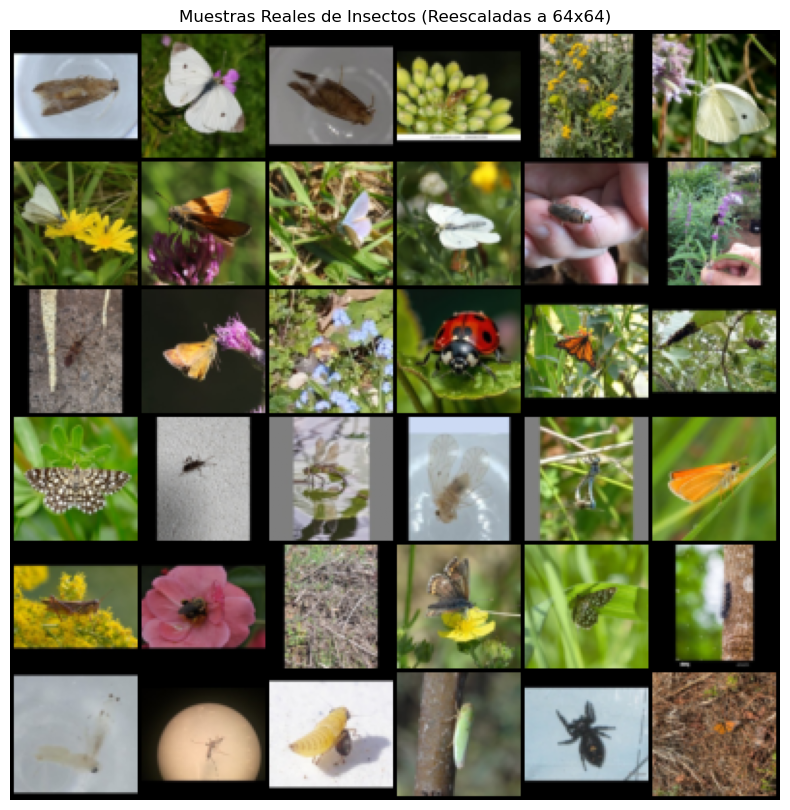

In [4]:
# Visualizar un lote de imágenes reales normalizadas
real_batch = next(iter(dataloader))
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Muestras Reales de Insectos (Reescaladas a 64x64)")
# Desnormalizar de [-1, 1] a [0, 1] para graficar
grid_img = utils.make_grid(real_batch[0][:36], nrow=6, padding=2, normalize=True)
plt.imshow(np.transpose(grid_img.cpu().numpy(), (1, 2, 0)))
plt.show()

## 3. Arquitectura DCGAN: Generador y Discriminador

- **Generador ($G$):** Recibe ruido latente $z \in \mathbb{R}^{100 \times 1 \times 1}$ y realiza un mapeo secuencial mediante convoluciones transpuestas con Batch Normalization hasta producir una imagen sintética de $3 \times 64 \times 64$.
- **Discriminador ($D$):** Recibe una imagen de $3 \times 64 \times 64$ y utiliza convoluciones con stride y `LeakyReLU` para clasificar si es real o sintética.

In [5]:
class Generator(nn.Module):
    def __init__(self, nz=NZ, ngf=NGF, nc=CHANNELS):
        super().__init__()
        self.main = nn.Sequential(
            # Entrada: vector latente Z de dimensión nz x 1 x 1
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # Estado: (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # Estado: (ngf*4) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # Estado: (ngf*2) x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # Estado: (ngf) x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh() # Salida: nc x 64 x 64 en rango [-1, 1]
        )

    def forward(self, x):
        return self.main(x)


class Discriminator(nn.Module):
    def __init__(self, nc=CHANNELS, ndf=NDF):
        super().__init__()
        self.main = nn.Sequential(
            # Entrada: nc x 64 x 64
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado: (ndf) x 32 x 32
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado: (ndf*2) x 16 x 16
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado: (ndf*4) x 8 x 8
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # Estado: (ndf*8) x 4 x 4 -> 1 x 1 x 1 logit
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)


# Inicialización canónica de pesos según Radford et al.
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Instanciación y aplicación de pesos
netG = Generator().to(device)
netD = Discriminator().to(device)
netG.apply(weights_init)
netD.apply(weights_init)
print("Modelos inicializados correctamente.")

Modelos inicializados correctamente.


## 4. Función de Pérdida, Optimizadores y Ruido Fijo

In [6]:
# BCEWithLogitsLoss combina Sigmoid + BCE en una capa numéricamente estable
criterion = nn.BCEWithLogitsLoss()

# Vector de ruido fijo para monitorear el avance visual de las mismas muestras época tras época
fixed_noise = torch.randn(36, NZ, 1, 1, device=device)

# Optimizadores Adam configurados según el estándar DCGAN
optimizerD = torch.optim.Adam(netD.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = torch.optim.Adam(netG.parameters(), lr=LR, betas=(BETA1, 0.999))

## 5. Bucle de Entrenamiento

En cada paso:
1. **Entrenamos el Discriminador:** Maximizar $\log D(x) + \log(1 - D(G(z)))$. Usamos suavizado unilateral de etiquetas reales ($0.9$) para evitar que $D$ domine a $G$.
2. **Entrenamos el Generador:** Maximizar $\log D(G(z))$ para que $G$ aprenda a engañar al Discriminador.

In [7]:
G_losses = []
D_losses = []
img_history = []

print(f"Iniciando entrenamiento por {EPOCHS} épocas...")
start_training = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    running_loss_D = 0.0
    running_loss_G = 0.0
    
    netD.train()
    netG.train()
    
    for i, (real_imgs, _) in enumerate(dataloader):
        b_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        
        # -----------------------------------------
        # (1) Actualizar Discriminador (D)
        # -----------------------------------------
        netD.zero_grad()
        
        # Lote real con one-sided label smoothing (0.9)
        label_real = torch.full((b_size, 1), 0.9, device=device)
        output_real = netD(real_imgs)
        loss_real = criterion(output_real, label_real)
        
        # Lote sintético
        noise = torch.randn(b_size, NZ, 1, 1, device=device)
        fake_imgs = netG(noise)
        label_fake = torch.zeros((b_size, 1), device=device)
        output_fake = netD(fake_imgs.detach())
        loss_fake = criterion(output_fake, label_fake)
        
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()
        
        # -----------------------------------------
        # (2) Actualizar Generador (G)
        # -----------------------------------------
        netG.zero_grad()
        label_gen = torch.ones((b_size, 1), device=device)
        output_g = netD(fake_imgs)
        loss_G = criterion(output_g, label_gen)
        loss_G.backward()
        optimizerG.step()
        
        running_loss_D += loss_D.item()
        running_loss_G += loss_G.item()
    
    # Promedios de la época
    avg_loss_D = running_loss_D / len(dataloader)
    avg_loss_G = running_loss_G / len(dataloader)
    D_losses.append(avg_loss_D)
    G_losses.append(avg_loss_G)
    epoch_time = time.time() - epoch_start
    
    print(f"Época [{epoch:02d}/{EPOCHS:02d}] - D Loss: {avg_loss_D:.4f} | G Loss: {avg_loss_G:.4f} ({epoch_time:.1f}s)")
    
    # Generar muestras con fixed_noise para verificar evolución visual
    with torch.no_grad():
        netG.eval()
        fake_samples = netG(fixed_noise).detach().cpu()
        img_history.append(utils.make_grid(fake_samples, nrow=6, normalize=True))

total_time = time.time() - start_training
print(f"\nEntrenamiento completado en {total_time / 60:.2f} minutos.")

Iniciando entrenamiento por 15 épocas...
Época [01/15] - D Loss: 0.7944 | G Loss: 6.6342 (69.3s)
Época [02/15] - D Loss: 0.7548 | G Loss: 3.3625 (47.2s)
Época [03/15] - D Loss: 0.7417 | G Loss: 3.3427 (46.9s)
Época [04/15] - D Loss: 0.7815 | G Loss: 3.0953 (46.9s)
Época [05/15] - D Loss: 0.7986 | G Loss: 2.8583 (46.8s)
Época [06/15] - D Loss: 0.8028 | G Loss: 2.8838 (46.4s)
Época [07/15] - D Loss: 0.8144 | G Loss: 2.7680 (46.5s)
Época [08/15] - D Loss: 0.8341 | G Loss: 2.7844 (46.6s)
Época [09/15] - D Loss: 0.8168 | G Loss: 2.8735 (46.3s)
Época [10/15] - D Loss: 0.7671 | G Loss: 2.8503 (47.2s)
Época [11/15] - D Loss: 0.8054 | G Loss: 2.8582 (47.6s)
Época [12/15] - D Loss: 0.8423 | G Loss: 2.8028 (50.2s)
Época [13/15] - D Loss: 0.8024 | G Loss: 2.7390 (47.4s)
Época [14/15] - D Loss: 0.8295 | G Loss: 2.7815 (47.7s)
Época [15/15] - D Loss: 0.7614 | G Loss: 2.7654 (47.3s)

Entrenamiento completado en 12.17 minutos.


## 6. Curvas de Aprendizaje

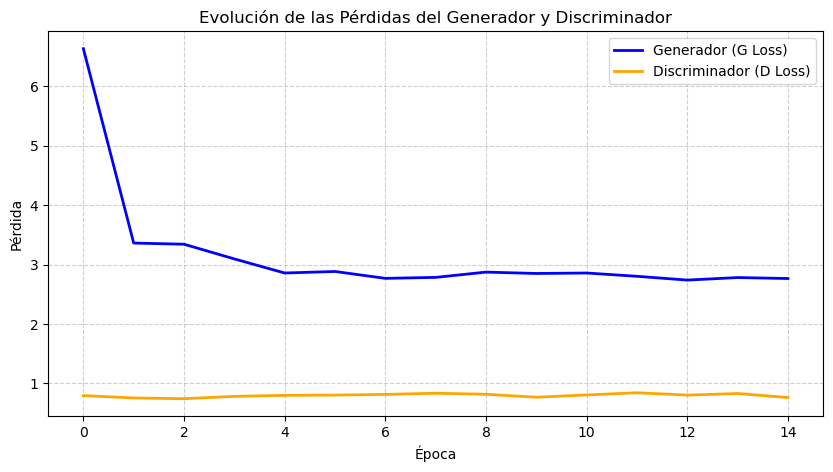

In [8]:
plt.figure(figsize=(10, 5))
plt.title("Evolución de las Pérdidas del Generador y Discriminador")
plt.plot(G_losses, label="Generador (G Loss)", color="blue", lw=2)
plt.plot(D_losses, label="Discriminador (D Loss)", color="orange", lw=2)
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## 7. Resultados Visuales: Imágenes de Insectos Generadas

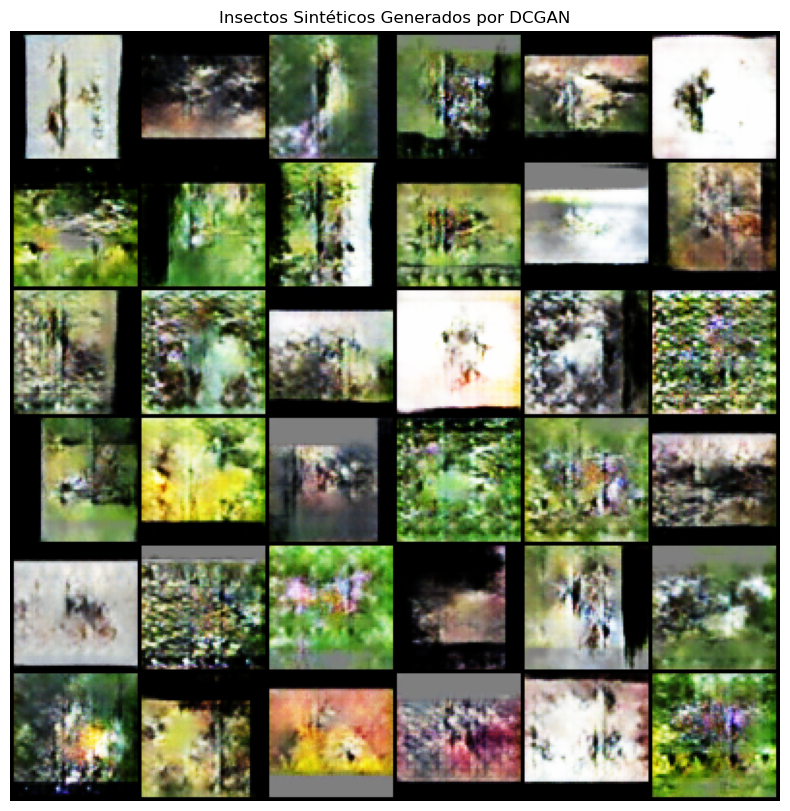

In [9]:
# Mostrar las muestras generadas por el modelo final
plt.figure(figsize=(10, 10))
plt.axis("off")
plt.title("Insectos Sintéticos Generados por DCGAN")
plt.imshow(np.transpose(img_history[-1], (1, 2, 0)))
plt.show()

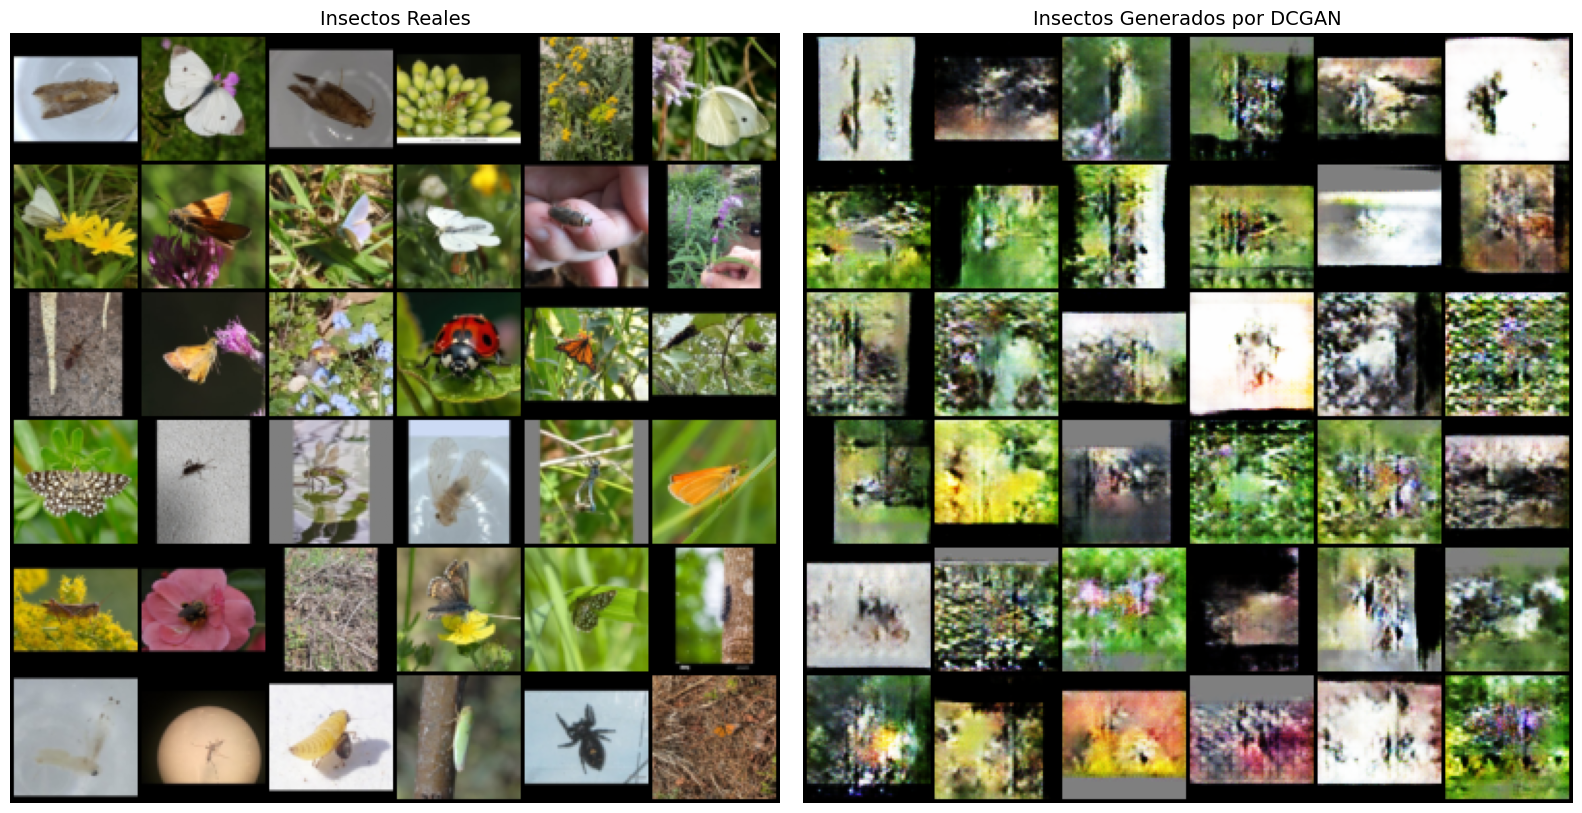

In [10]:
# Comparación lado a lado: Reales vs Generados
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].axis("off")
axes[0].set_title("Insectos Reales", fontsize=14)
axes[0].imshow(np.transpose(grid_img.cpu().numpy(), (1, 2, 0)))

axes[1].axis("off")
axes[1].set_title("Insectos Generados por DCGAN", fontsize=14)
axes[1].imshow(np.transpose(img_history[-1].numpy(), (1, 2, 0)))
plt.tight_layout()
plt.show()

## 8. Guardar el Modelo Entrenado

In [11]:
# Guardar los pesos del generador para inferencia futura
model_path = "generator_insects.pth"
torch.save(netG.state_dict(), model_path)
print(f"Modelo generador guardado exitosamente en: {model_path}")

Modelo generador guardado exitosamente en: generator_insects.pth
